# Desigualdades Socioespaciais em Fortaleza - Trabalho Prático Final (AP3)
## CK0441 - Laboratório de Ciência de Dados

---

## 1. Definição do Problema

### 1.1 Contexto

Fortaleza é a quinta maior cidade do Brasil, com aproximadamente 2,5 milhões de habitantes segundo o Censo 2022. Apesar de concentrar o principal polo econômico do nordeste, a cidade apresenta profundas disparidades internas: bairros de alta renda convivem espacialmente com comunidades urbanas e favelas que registram rendimentos mensais próximos ao salário mínimo.

Essa segmentação socioespacial tem implicações diretas em acesso a serviços, qualidade de vida e mobilidade social. Entender **onde** e **como** essa desigualdade se manifesta no espaço urbano é o primeiro passo para criar políticas públicas mais eficazes.

### 1.2 Pergunta de Pesquisa

> **Como a desigualdade de renda e as características demográficas se distribuem espacialmente pelos setores censitários e bairros de Fortaleza, e quais padrões estruturais essa distribuição revela?**

### 1.3 Perguntas Secundárias

1. Onde estão localizados os bairros de alta e baixa renda?
2. Como se distribui a renda mediana por tipo de domicílio?
3. Como se distribui a renda mediana da população?
4. Quais bairros concentram os maiores e menores rendimentos medianos domiciliares?
5. Existe correlação entre densidade populacional, tipo de setor censitário (ex.: favela) e baixa renda?

### 1.4 Fontes de Dados

Todos os dados utilizados são **abertos e públicos**, provenientes do **Censo Demográfico 2022 do IBGE**:

| Arquivo | Descrição | URL |
|---------|-----------|-----|
| `CE_setores_CD2022.gpkg` | Malha vetorial de setores censitários do Ceará | [IBGE – Malhas territoriais](https://www.ibge.gov.br/geociencias/downloads-geociencias.html) |
| `Agregados_por_setores_demografia_BR.csv` | Variáveis demográficas por setor (população por sexo e faixa etária) | [IBGE – Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados) |
| `Agregados_por_setores_renda_responsavel_BR.csv` | Rendimento do responsável pelo domicílio por setor | [IBGE – Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados) |

### 1.5 Metodologia

O projeto segue o pipeline clássico de Ciência de Dados:

```
Obtenção dos dados → Limpeza e preparação → Análise Exploratória → Visualização → Conclusões
```

A unidade de análise principal é o **setor censitário** (menor unidade territorial do IBGE), com agregações também realizadas em nível de **bairro**.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

## 2. Configuração do ambiente

In [ ]:
import urllib.request
import pandas as pd
import geopandas as gpd

BASE_URL = "https://github.com/NatanielMarques14/desigualdades-socioespaciais-fortaleza/releases/download/v1.0/"

arquivos = [
    "CE_setores_CD2022.gpkg",
    "dicionario_de_dados_malha_agregados.xlsx",
    "Agregados_por_setores_renda_responsavel_BR.csv",
    "dicionario_de_dados_renda_responsavel_20260508.xlsx",
    "Agregados_por_setores_demografia_BR.csv"
]

# Download dos arquivos
for arquivo in arquivos:
    print(f"Baixando {arquivo}...")
    urllib.request.urlretrieve(BASE_URL + arquivo, arquivo)

print("Todos os arquivos foram baixados!\n")

# GeoPackage
setores_ce = gpd.read_file("CE_setores_CD2022.gpkg")

# Dicionário da malha
dicio = pd.read_excel(
    "dicionario_de_dados_malha_agregados.xlsx"
)

# Renda
renda_br = pd.read_csv(
    "Agregados_por_setores_renda_responsavel_BR.csv",
    sep=";",
    dtype={"CD_SETOR": str}
)

# Dicionário da renda
dicio_renda = pd.read_excel(
    "dicionario_de_dados_renda_responsavel_20260508.xlsx"
)

# Demografia
demo_br = pd.read_csv(
    "Agregados_por_setores_demografia_BR.csv",
    sep=";",
    dtype={"CD_setor": str}
)

print("Arquivos carregados com sucesso!")

Baixando CE_setores_CD2022.gpkg...
Baixando dicionario_de_dados_malha_agregados.xlsx...
Baixando Agregados_por_setores_renda_responsavel_BR.csv...
Baixando dicionario_de_dados_renda_responsavel_20260508.xlsx...
Baixando Agregados_por_setores_demografia_BR.csv...
Todos os arquivos foram baixados!



/tmp/ipykernel_846/1813991440.py:43: DtypeWarning: Columns (1,2,3,4,9,18,25,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  demo_br = pd.read_csv(


Arquivos carregados com sucesso!


instalando o plotly para visualização interativa

In [ ]:
!pip install -q plotly mapclassify

In [ ]:
# Outros imports

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd # como iremos manipular nossos arquivos geográficos/geométricos

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Patch

# padrão para o uso do geopandas v

%matplotlib inline
print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


---
## 3. Obtenção e Carregamento dos Dados

### 3.1 Malha de Setores Censitários do Ceará

Os **setores censitários** são a menor unidade territorial operacional do IBGE, o nível mais detalhado em que os dados do censo são coletados e divulgados. O arquivo `CE_setores_CD2022.gpkg` (formato GeoPackage) contém os polígonos geográficos de todos os setores do estado do Ceará.

O carregamento é feito com `geopandas.read_file()`, que retorna um `GeoDataFrame`, uma extensão do `DataFrame` do pandas com uma coluna especial `geometry` contendo as geometrias vetoriais de cada setor.

> **Download:** os arquivos de malha por UF estão disponíveis no [site do IBGE](https://www.ibge.gov.br/geociencias/downloads-geociencias.html), em Organização do Território > Malhas Territoriais > Malhas de Setores Censitários > Censo 2022 > Setores > gpkg > UF > CE > CE_setores_CD2022.gpkg.

In [ ]:


print(f"Setores no Ceará: {len(setores_ce):,}")
print(f"CRS (sistema de referência): {setores_ce.crs}")
print(f"\nColunas ({len(setores_ce.columns)}):")
setores_ce.columns.tolist()

Setores no Ceará: 20,982
CRS (sistema de referência): EPSG:4674

Colunas (30):


['CD_SETOR',
 'SITUACAO',
 'CD_SIT',
 'CD_TIPO',
 'AREA_KM2',
 'CD_REGIAO',
 'NM_REGIAO',
 'CD_UF',
 'NM_UF',
 'CD_MUN',
 'NM_MUN',
 'CD_DIST',
 'NM_DIST',
 'CD_SUBDIST',
 'NM_SUBDIST',
 'CD_BAIRRO',
 'NM_BAIRRO',
 'CD_NU',
 'NM_NU',
 'CD_FCU',
 'NM_FCU',
 'CD_AGLOM',
 'NM_AGLOM',
 'CD_RGINT',
 'NM_RGINT',
 'CD_RGI',
 'NM_RGI',
 'CD_CONCURB',
 'NM_CONCURB',
 'geometry']

O CRS (Coordinate Reference System) define como as coordenadas armazenadas no arquivo devem ser interpretadas na superfície da Terra. No caso dos nossos dados temos que o CRS é EPSG:4674. EPSG é um catálogo internacional de sistemas de coordenadas com cada CRS tendo um código EPSG único.

Observação: EPSG:4674 (SIRGAS 2000) e EPSG:4326 (WGS84) usam latitude e longitude em graus, enquanto EPSG:31984 (UTM 24S) e EPSG:31985 (UTM 25S) usam coordenadas em metros, sendo mais adequados para cálculos de área e distância.

isso significa que os dados estão no sistema geodésico SIRGAS 2000 que é o sistema de referência oficial adotado pelo Brasil para cartografia e geoprocessamento.

Ele define:

- o formato da Terra (elipsoide);
- a posição do sistema de coordenadas;
- como latitude e longitude são medidas.


In [ ]:
print(f"Linhas do dicionário: {len(dicio):,}")
print(f"Colunas: {len(dicio.columns)}")

dicio.head(56)

Linhas do dicionário: 56
Colunas: 3


,VARIÁVEL,CATEGORIAS,DESCRIÇÃO
0,CD_SETOR,NaN,Geocódigo de Setor Censitário
1,SITUACAO,NaN,Situação do Setor Censitário
2,NaN,Urbana,Urbana
3,NaN,Rural,Rural
4,CD_SITUACAO,NaN,Situação detalhada do Setor Censitário
5,NaN,1,Área urbana de alta densidade de edificações d...
6,NaN,2,Área urbana de baixa densidade de edificações ...
7,NaN,3,Núcleo urbano
8,NaN,5,Aglomerado rural - Povoado
9,NaN,6,Aglomerado rural - Núcleo rural


### 3.2 Dicionário de colunas: Malha de Setores Censitários

Fonte: `Dicionario_de_dados_malha_agregados.xlsx`, Censo Demográfico 2022 - [IBGE](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados).


| Coluna | Descrição |
|--------|-----------|
| `CD_SETOR` | Geocódigo único do setor censitário (15 dígitos) |
| `SITUACAO` | Situação geral do setor: `Urbana` ou `Rural` |
| `CD_SIT` | Situação detalhada: `1` Urbana alta densidade · `2` Urbana baixa densidade · `3` Núcleo urbano · `5` Aglomerado rural – Povoado · `6` Aglomerado rural – Núcleo rural · `7` Aglomerado rural – Lugarejo · `8` Área rural · `9` Massas de água |
| `CD_TIPO` | Tipo especial do setor: `0` Comum · `1` Favela/Comunidade Urbana · `2` Quartel/Base militar · `3` Alojamento/Acampamento · `4` Baixo patamar domiciliar · `5` Agrupamento indígena · `6` Unidade prisional · `7` Convento/Hospital/ILPI · `8` Agrovila do PA · `9` Agrupamento quilombola |
| `AREA_KM2` | Área do setor em quilômetros quadrados |
| `CD_REGIAO` / `NM_REGIAO` | Código e nome da Grande Região (ex: `2` - Nordeste) |
| `CD_UF` / `NM_UF` | Código e nome da Unidade da Federação (ex: `23` - Ceará) |
| `CD_MUN` / `NM_MUN` | Código e nome do Município |
| `CD_DIST` / `NM_DIST` | Código e nome do Distrito |
| `CD_SUBDIST` / `NM_SUBDIST` | Código e nome do Subdistrito |
| `CD_BAIRRO` / `NM_BAIRRO` | Código e nome do Bairro (quando disponível) |
| `CD_NU` / `NM_NU` | Código e nome do Núcleo Urbano |
| `CD_FCU` / `NM_FCU` | Código e nome da Favela ou Comunidade Urbana |
| `CD_AGLOM` / `NM_AGLOM` | Código e nome do Aglomerado (rural ou urbano) |
| `CD_RGINT` / `NM_RGINT` | Código e nome da Região Geográfica Intermediária |
| `CD_RGI` / `NM_RGI` | Código e nome da Região Geográfica Imediata |
| `CD_CONCURB` / `NM_CONCURB` | Código e nome da Concentração Urbana |
| `geometry` | Polígono vetorial do setor (tipo `MultiPolygon` ou `Polygon`) |

### 3.3 Filtrando os Setores de Fortaleza

O GeoDataFrame do Ceará contém setores de todos os municípios do estado. Filtramos apenas Fortaleza pelo nome do município (`NM_MUN`).

Para análise posterior, mantemos apenas as colunas mais relevantes da malha, descartando campos de outras divisões administrativas que não serão usados.

In [ ]:
setores_fortaleza = setores_ce[setores_ce["NM_MUN"] == "Fortaleza"].copy()

colunas_interesse = [
    "CD_SETOR", "SITUACAO", "CD_SIT", "CD_TIPO",
    "AREA_KM2", "NM_BAIRRO", "geometry"
]
setores_fortaleza = setores_fortaleza[colunas_interesse].reset_index(drop=True)

# mapeando tipos legíveis
tipo_map = {
    '0': 'Comum', '1': 'Favela/Comunidade Urbana',
    '2': 'Quartel/Base militar', '3': 'Alojamento/Acampamento',
    '4': 'Baixo patamar domiciliar', '5': 'Agrupamento indígena',
    '6': 'Unidade prisional', '7': 'Convento/Hospital/ILPI',
    '8': 'Agrovila do PA', '9': 'Agrupamento quilombola'
}
setores_fortaleza['TIPO_LABEL'] = setores_fortaleza['CD_TIPO'].map(tipo_map).fillna('Outro')

print(f'Setores censitários em Fortaleza: {len(setores_fortaleza):,}')
print(f'\nDistribuição por tipo especial:')
print(setores_fortaleza['TIPO_LABEL'].value_counts().to_string())

Setores censitários em Fortaleza: 4,408

Distribuição por tipo especial:
TIPO_LABEL
Comum                       2952
Favela/Comunidade Urbana    1321
Baixo patamar domiciliar     133
Convento/Hospital/ILPI         2


In [ ]:
print(setores_fortaleza.columns)

Index(['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'NM_BAIRRO',
       'geometry', 'TIPO_LABEL'],
      dtype='object')


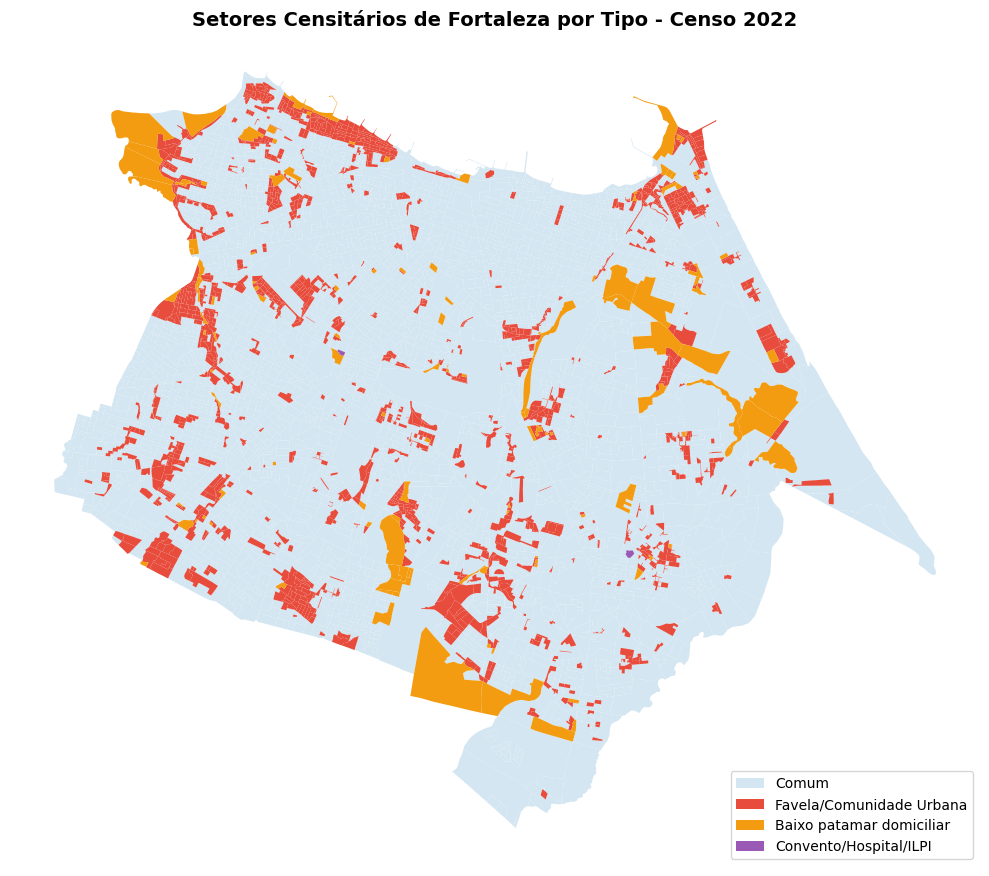

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

cores = {
    'Comum': '#d4e6f1',
    'Favela/Comunidade Urbana': '#e74c3c',
    'Baixo patamar domiciliar': '#f39c12',
    'Convento/Hospital/ILPI': '#9b59b6',
}

for tipo, cor in cores.items():
    subset = setores_fortaleza[setores_fortaleza['TIPO_LABEL'] == tipo]
    if len(subset) > 0:
        subset.plot(ax=ax, color=cor, edgecolor='none', linewidth=0.2, label=f'{tipo} ({len(subset):,})')

outros = setores_fortaleza[~setores_fortaleza['TIPO_LABEL'].isin(cores.keys())]
if len(outros) > 0:
    outros.plot(ax=ax, color='#bdc3c7', edgecolor='none', linewidth=0.2, label=f'Outros ({len(outros):,})')
legendas = [
    Patch(facecolor=cor, label=tipo)
    for tipo, cor in cores.items()
]

ax.legend(handles=legendas, loc="lower right")
ax.set_title('Setores Censitários de Fortaleza por Tipo - Censo 2022', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('mapa_tipo_setor.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Visualizando Dados Demográficos Agregados por Setor

O arquivo `Agregados_por_setores_demografia_BR.csv` contém variáveis demográficas do [Censo 2022](https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html?edicao=41852&t=resultados) (Pessoas), para todos os setores censitários do Brasil.


In [ ]:
demo_br = demo_br.rename(columns={'CD_setor': 'CD_SETOR'})
# Filtra apenas Fortaleza (código município = 230440)
demo_for = demo_br[demo_br['CD_SETOR'].str.startswith('230440')].copy()

print(f'Setores demográficos de Fortaleza: {len(demo_for):,}')
print(f'Colunas: {demo_for.columns.tolist()}')
demo_for.head()

Setores demográficos de Fortaleza: 4,306
Colunas: ['CD_SETOR', 'V01006', 'V01007', 'V01008', 'V01009', 'V01010', 'V01011', 'V01012', 'V01013', 'V01014', 'V01015', 'V01016', 'V01017', 'V01018', 'V01019', 'V01020', 'V01021', 'V01022', 'V01023', 'V01024', 'V01025', 'V01026', 'V01027', 'V01028', 'V01029', 'V01030', 'V01031', 'V01032', 'V01033', 'V01034', 'V01035', 'V01036', 'V01037', 'V01038', 'V01039', 'V01040', 'V01041']


,CD_SETOR,V01006,V01007,V01008,V01009,V01010,V01011,V01012,V01013,V01014,...,V01032,V01033,V01034,V01035,V01036,V01037,V01038,V01039,V01040,V01041
66851,230440005130001,866,411,455,25,38,29,31,39,37,...,71,58,64,76,70,134,111,118,62,44
66852,230440005130002,35,22,13,X,0,X,X,X,0,...,0,3,X,X,0,5,10,5,6,X
66853,230440005130003,125,66,59,4,X,X,X,11,4,...,6,3,9,16,7,24,18,23,10,4
66854,230440005130004,266,125,141,5,4,7,7,15,13,...,8,11,15,23,22,48,39,39,29,23
66855,230440005130005,X,X,X,X,X,X,X,X,X,...,X,X,X,X,X,X,X,X,X,X


### Dicionário de variáveis - Agregados Demográficos

Fonte: documentação dos Agregados por Setores Censitários, [Agregados por Setores Censitários:
Resultados do universo](https://agenciadenoticias.ibge.gov.br/media/com_mediaibge/arquivos/0b3f95b42688832ce81891a89f5b7a88.pdf).

| Coluna | Descrição |
|--------|-----------|
| `CD_setor` | Geocódigo do setor censitário - chave de junção com a malha |
| `V01006` | Total de pessoas residentes |
| `V01007` | Homens (total) |
| `V01008` | Mulheres (total) |
| `V01009` | 0 anos |
| `V01010` | 1 a 4 anos |
| `V01011` | 5 a 9 anos |
| `V01012` | 10 a 14 anos |
| `V01013` | 15 a 19 anos |
| `V01014` | 20 a 24 anos |
| `V01015` | 25 a 29 anos |
| `V01016` | 30 a 34 anos |
| `V01017` | 35 a 39 anos |
| `V01018` | 40 a 44 anos |
| `V01019` | 45 a 49 anos |
| `V01020` | 50 a 54 anos |
| `V01021` | 55 a 59 anos |
| `V01022` | 60 a 64 anos |
| `V01023` | 65 a 69 anos |
| `V01024` | 70 a 74 anos |
| `V01025` | 75 a 79 anos |
| `V01026` | 80 a 84 anos |
| `V01027` | 85 a 89 anos |
| `V01028` | 90 a 94 anos |
| `V01029` | 95 a 99 anos |
| `V01030` | 100 anos ou mais |
| `V01031`–`V01041` | Variáveis demográficas complementares |

> As variáveis `V01009` a `V01030` somam o total de `V01006` para cada setor.

### 3.5 Visualizando Dados de Renda

In [ ]:
renda_for = renda_br[renda_br['CD_SETOR'].str.startswith('230440')].copy()

print(f'Setores de renda de Fortaleza: {len(renda_for):,}')
print(f'Colunas: {renda_for.columns.tolist()}')
renda_for.head()

Setores de renda de Fortaleza: 4,306
Colunas: ['CD_SETOR', 'V06001', 'V06002', 'V06003', 'V06004', 'V06005', 'V06006']


,CD_SETOR,V06001,V06002,V06003,V06004,V06005,V06006
66851,230440005130001,283,866,3.39,1474.07,1097897.04,1212
66852,230440005130002,19,35,1.14,1664.47,795855.76,1212
66853,230440005130003,61,125,1.91,3315.34,32772153.16,1800
66854,230440005130004,113,260,1.94,2979.64,9419349.59,2000
66855,230440005130005,X,X,X,X,X,X


In [ ]:
print(f"Linhas do dicionário: {len(dicio_renda):,}")
print(f"Colunas: {len(dicio_renda.columns)}")

dicio_renda.head(10)

Linhas do dicionário: 6
Colunas: 3


,Tema,Variável,Descrição
0,Renda do Responsável,V06001,Pessoas responsáveis em domicílios particulare...
1,Renda do Responsável,V06002,Moradores em domicílios particulares permanent...
2,Renda do Responsável,V06003,Variância do número de moradores em domicílios...
3,Renda do Responsável,V06004,Valor do rendimento nominal médio mensal das p...
4,Renda do Responsável,V06005,Variância do rendimento nominal mensal das pes...
5,Renda do Responsável,V06006,Valor do rendimento nominal mediano mensal das...


---
## 4. Limpeza e Preparação dos Dados

### 4.1 Tratamento de Valores Faltantes e Inconsistentes

O IBGE usa o código `'X'` para suprimir dados de setores com poucos domicílios (proteção ao sigilo estatístico). Esses valores precisam ser convertidos para `NaN` antes de qualquer análise numérica.

In [ ]:


# pra demografia
# seleciona colunas de interesse: total de pessoas por sexo
# V01006 = total de pessoas, V01007 = homens, V01008 = mulheres
cols_demo = [c for c in demo_for.columns if c.startswith('V')]
demo_limpo = demo_for[['CD_SETOR'] + cols_demo].copy()

# substitui 'X' e '-' por NaN e converte para numérico
for col in cols_demo:
    demo_limpo[col] = pd.to_numeric(
        demo_limpo[col].astype(str).str.strip().replace({'X': np.nan, '-': np.nan}),
        errors='coerce'
    )

total_X_demo = demo_for[cols_demo].isin(['X', 'x']).sum().sum()
total_nan_demo = demo_limpo[cols_demo].isna().sum().sum()

print('Dados Demográficos')
print(f'Valores suprimidos (X): {total_X_demo:,}')
print(f'Valores NaN após limpeza: {total_nan_demo:,}')
print(f'Setores sem dados demográficos completos: {demo_limpo[cols_demo].isna().any(axis=1).sum():,}')

Dados Demográficos
Valores suprimidos (X): 4,235
Valores NaN após limpeza: 4,235
Setores sem dados demográficos completos: 840


In [ ]:
# pra renda
cols_renda = [c for c in renda_for.columns if c.startswith('V')]
renda_limpo = renda_for[['CD_SETOR'] + cols_renda].copy()

for col in cols_renda:
    renda_limpo[col] = pd.to_numeric(
        renda_limpo[col].astype(str).str.strip().replace({'X': np.nan, '-': np.nan, '..': np.nan}),
        errors='coerce'
    )

total_nan_renda = renda_limpo[cols_renda].isna().sum().sum()

print('Dados de Renda')
print(f'Valores NaN após limpeza: {total_nan_renda:,}')
print(f'Setores sem renda mediana: {renda_limpo["V06006"].isna().sum():,}')

Dados de Renda
Valores NaN após limpeza: 157
Setores sem renda mediana: 26


### 4.2 Integração dos Datasets

In [ ]:
# seleciona as colunas demográficas principais
# Padroniza o nome da chave
demo_limpo = demo_limpo.rename(columns={'CD_setor': 'CD_SETOR'})
colunas_demo_sel = ['CD_SETOR']
if 'V01006' in demo_limpo.columns:
    colunas_demo_sel += ['V01006', 'V01007', 'V01008']  # total, homens, mulheres
else:
    colunas_demo_sel += [c for c in cols_demo[:3]]  # pega as 3 primeiras

df_merged = (
    setores_fortaleza
    .merge(demo_limpo[colunas_demo_sel], on='CD_SETOR', how='left')
    .merge(renda_limpo[['CD_SETOR', 'V06006']], on='CD_SETOR', how='left')
)

# Renomear para nomes legíveis
rename_map = {}
if 'V01006' in df_merged.columns:
    rename_map.update({'V01006': 'POP_TOTAL', 'V01007': 'POP_HOMENS', 'V01008': 'POP_MULHERES'})
rename_map['V06006'] = 'RENDA_MEDIANA'
df_merged = df_merged.rename(columns=rename_map)

# Calcula densidade populacional (hab/km²)
if 'POP_TOTAL' in df_merged.columns:
    df_merged['DENSIDADE'] = df_merged['POP_TOTAL'] / df_merged['AREA_KM2']
    df_merged['RAZAO_SEXO'] = (df_merged['POP_HOMENS'] / df_merged['POP_MULHERES'] * 100).round(1)

print(f'Dataset integrado: {len(df_merged):,} setores, {len(df_merged.columns)} colunas')
print(f'Cobertura de renda mediana: {df_merged["RENDA_MEDIANA"].notna().sum():,} setores')
df_merged.head()

Dataset integrado: 4,408 setores, 14 colunas
Cobertura de renda mediana: 4,280 setores


,CD_SETOR,SITUACAO,CD_SIT,CD_TIPO,AREA_KM2,NM_BAIRRO,geometry,TIPO_LABEL,POP_TOTAL,POP_HOMENS,POP_MULHERES,RENDA_MEDIANA,DENSIDADE,RAZAO_SEXO
0,230440005130001,Urbana,1,1,0.044470,Centro,"POLYGON ((-38.51992 -3.71861, -38.51991 -3.718...",Favela/Comunidade Urbana,866.0,411.0,455.0,1212.0,19473.650708,90.3
1,230440005130002,Urbana,2,0,0.186817,Centro,"POLYGON ((-38.5199 -3.71783, -38.51991 -3.7181...",Comum,35.0,22.0,13.0,1212.0,187.349096,169.2
2,230440005130003,Urbana,1,0,0.316550,Centro,"POLYGON ((-38.52888 -3.72454, -38.52778 -3.724...",Comum,125.0,66.0,59.0,1800.0,394.881966,111.9
3,230440005130004,Urbana,2,0,0.412278,Centro,"POLYGON ((-38.52102 -3.72103, -38.52104 -3.721...",Comum,266.0,125.0,141.0,2000.0,645.195429,88.7
4,230440005130005,Urbana,1,0,0.118974,Centro,"POLYGON ((-38.52888 -3.72454, -38.53 -3.72419,...",Comum,NaN,NaN,NaN,NaN,NaN,NaN


### 4.3 Agregação por Bairro

In [ ]:
agg_dict = {
    'AREA_KM2': 'sum',
    'RENDA_MEDIANA': 'median',
    'CD_SETOR': 'count',
}
if 'POP_TOTAL' in df_merged.columns:
    agg_dict.update({
        'POP_TOTAL': 'sum',
        'POP_HOMENS': 'sum',
        'POP_MULHERES': 'sum',
    })

bairros = (
    df_merged.dropna(subset=['NM_BAIRRO'])
    .groupby('NM_BAIRRO')
    .agg(agg_dict)
    .reset_index()
    .rename(columns={'CD_SETOR': 'N_SETORES'})
)

if 'POP_TOTAL' in bairros.columns:
    bairros['DENSIDADE'] = bairros['POP_TOTAL'] / bairros['AREA_KM2']
    bairros['RAZAO_SEXO'] = (bairros['POP_HOMENS'] / bairros['POP_MULHERES'] * 100).round(1)

# Agrega geometria por bairro (união dos polígonos)
bairros_geo = (
    df_merged.dropna(subset=['NM_BAIRRO'])
    .dissolve(by='NM_BAIRRO', aggfunc='first')
    .reset_index()[['NM_BAIRRO', 'geometry']]
)
bairros = bairros.merge(bairros_geo, on='NM_BAIRRO', how='left')
bairros_gdf = gpd.GeoDataFrame(bairros, geometry='geometry', crs=setores_fortaleza.crs)

print(f'Bairros com dados: {len(bairros_gdf):,}')
print(f'Cobertura de renda por bairro: {bairros_gdf["RENDA_MEDIANA"].notna().sum()}')
bairros_gdf.sort_values('RENDA_MEDIANA', ascending=False).head(10)

Bairros com dados: 121
Cobertura de renda por bairro: 121


,NM_BAIRRO,AREA_KM2,RENDA_MEDIANA,N_SETORES,POP_TOTAL,POP_HOMENS,POP_MULHERES,DENSIDADE,RAZAO_SEXO,geometry
26,Cocó,3.262280,10000.0,33,23005.0,10339.0,12666.0,7051.816571,81.6,"POLYGON ((-38.4939 -3.7492, -38.49387 -3.74916..."
51,Guararapes,1.364503,10000.0,10,7642.0,3490.0,4152.0,5600.573776,84.1,"POLYGON ((-38.48263 -3.76367, -38.48258 -3.764..."
71,Meireles,2.640134,9250.0,68,38374.0,17038.0,21336.0,14534.870293,79.9,"POLYGON ((-38.50768 -3.73005, -38.50812 -3.729..."
2,Aldeota,3.881269,8000.0,66,42580.0,18579.0,24001.0,10970.638818,77.4,"POLYGON ((-38.50581 -3.7426, -38.50633 -3.7424..."
39,Dionísio Torres,1.725351,7000.0,28,13875.0,5958.0,7917.0,8041.840824,75.3,"POLYGON ((-38.50443 -3.75288, -38.5049 -3.7527..."
86,Parque Iracema,1.565778,6000.0,24,13669.0,6256.0,7413.0,8729.845806,84.4,"POLYGON ((-38.49921 -3.81322, -38.49934 -3.812..."
115,Varjota,0.532034,5000.0,13,6703.0,2984.0,3719.0,12598.813326,80.2,"POLYGON ((-38.48845 -3.73949, -38.48845 -3.739..."
46,Fátima,2.861188,5000.0,40,23114.0,10052.0,13062.0,8078.461839,77.0,"POLYGON ((-38.52794 -3.75933, -38.52813 -3.759..."
35,De Lourdes,1.366039,5000.0,3,2310.0,1100.0,1210.0,1691.020882,90.9,"POLYGON ((-38.45875 -3.74294, -38.45861 -3.743..."
19,Cambeba,2.742091,4875.0,21,8775.0,4082.0,4693.0,3200.112108,87.0,"POLYGON ((-38.48451 -3.81756, -38.48471 -3.817..."


### 4.4 Exportando Dados Tratados

In [ ]:
# Exporta sem geometria
cols_export = [c for c in df_merged.columns if c != 'geometry']
df_merged[cols_export].to_csv('setores_fortaleza_limpo.csv', index=False)

# Bairros
cols_bairro_export = [c for c in bairros_gdf.columns if c != 'geometry']
bairros_gdf[cols_bairro_export].to_csv('bairros_fortaleza_agregado.csv', index=False)

print('Arquivos exportados:')
print('  setores_fortaleza_limpo.csv')
print('  bairros_fortaleza_agregado.csv')

Arquivos exportados:
  setores_fortaleza_limpo.csv
  bairros_fortaleza_agregado.csv


---
## 5. Análise Exploratória de Dados

### 5.1 Estatísticas Descritivas Gerais

In [ ]:
colunas_num = [c for c in ['POP_TOTAL', 'AREA_KM2', 'DENSIDADE', 'RENDA_MEDIANA', 'RAZAO_SEXO']
               if c in df_merged.columns]

stats = df_merged[colunas_num].describe().T
stats.columns = ['n', 'média', 'desvio padrão', 'mín', 'Q1', 'mediana', 'Q3', 'máx']
stats = stats.round(2)
print('Estatísticas descritivas: setores censitários de Fortaleza (Censo 2022)')
stats

Estatísticas descritivas: setores censitários de Fortaleza (Censo 2022)


,n,média,desvio padrão,mín,Q1,mediana,Q3,máx
POP_TOTAL,4280.0,567.41,306.33,9.00,353.00,561.00,750.00,3956.00
AREA_KM2,4408.0,0.07,0.19,0.00,0.02,0.04,0.07,5.21
DENSIDADE,4280.0,17568.45,17366.23,12.86,8862.23,14700.33,23053.77,629543.81
RENDA_MEDIANA,4280.0,2109.52,2137.07,400.00,1212.00,1212.00,2000.00,20001.00
RAZAO_SEXO,4280.0,87.66,11.27,26.70,81.20,86.95,93.10,234.10


In [ ]:
print(' Estatísticas da Renda Mediana por Bairro ')
print(bairros_gdf['RENDA_MEDIANA'].describe().round(2))

print('\n--- 10 bairros com MAIOR renda mediana ---')
print(bairros_gdf.nlargest(10, 'RENDA_MEDIANA')[['NM_BAIRRO', 'RENDA_MEDIANA']].to_string(index=False))

print('\n--- 10 bairros com MENOR renda mediana ---')
print(bairros_gdf.nsmallest(10, 'RENDA_MEDIANA')[['NM_BAIRRO', 'RENDA_MEDIANA']].to_string(index=False))

 Estatísticas da Renda Mediana por Bairro 
count      121.00
mean      1971.78
std       1738.89
min       1200.00
25%       1212.00
50%       1212.00
75%       1620.00
max      10000.00
Name: RENDA_MEDIANA, dtype: float64

--- 10 bairros com MAIOR renda mediana ---
      NM_BAIRRO  RENDA_MEDIANA
           Cocó        10000.0
     Guararapes        10000.0
       Meireles         9250.0
        Aldeota         8000.0
Dionísio Torres         7000.0
 Parque Iracema         6000.0
     De Lourdes         5000.0
         Fátima         5000.0
        Varjota         5000.0
        Cambeba         4875.0

--- 10 bairros com MENOR renda mediana ---
               NM_BAIRRO  RENDA_MEDIANA
                 Barroso         1200.0
              Aerolândia         1206.0
Parque Presidente Vargas         1206.5
               Aeroporto         1212.0
         Alto da Balança         1212.0
                  Ancuri         1212.0
                 Aracapé         1212.0
            Autran Nunes    

### 5.2 Distribuição da Renda Mediana

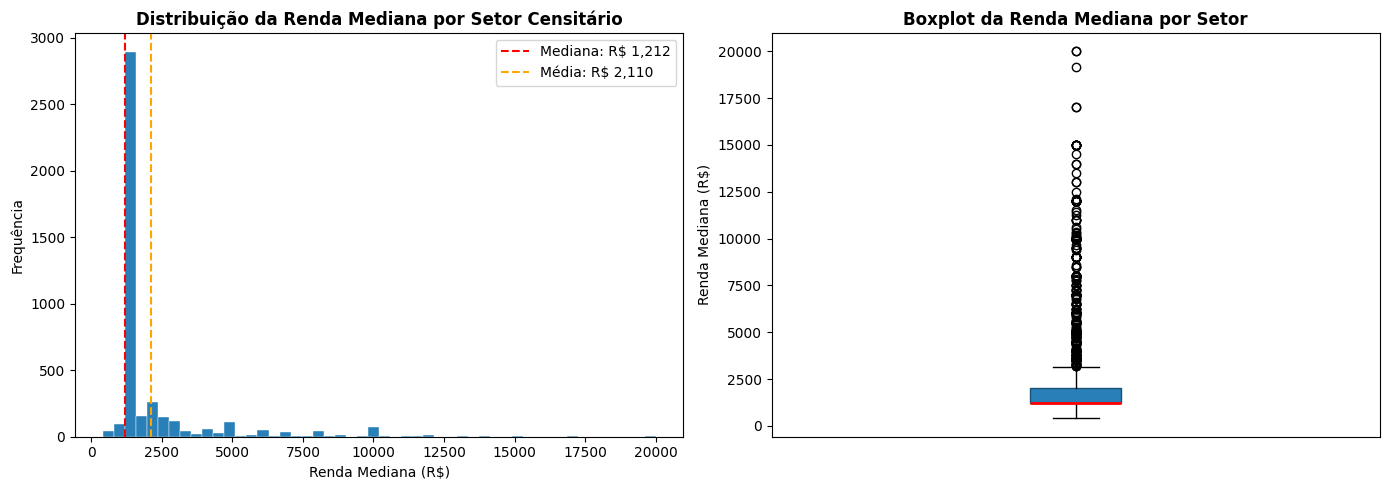


Coeficiente de Gini da renda mediana por setor: 0.3696
(0 = igualdade perfeita; 1 = desigualdade máxima)


In [ ]:
renda_valida = df_merged['RENDA_MEDIANA'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogramas
axes[0].hist(renda_valida, bins=50, color='#2980b9', edgecolor='white', linewidth=0.3)
axes[0].axvline(renda_valida.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mediana: R$ {renda_valida.median():,.0f}')
axes[0].axvline(renda_valida.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Média: R$ {renda_valida.mean():,.0f}')
axes[0].set_title('Distribuição da Renda Mediana por Setor Censitário', fontweight='bold')
axes[0].set_xlabel('Renda Mediana (R$)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# boxplot
axes[1].boxplot(renda_valida, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2980b9', color='#1a5276'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot da Renda Mediana por Setor', fontweight='bold')
axes[1].set_ylabel('Renda Mediana (R$)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('dist_renda_setores.png', dpi=150, bbox_inches='tight')
plt.show()

# coeficiente de Gini simplificado
def gini(x):
    x = np.sort(x.dropna().values)
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n

g = gini(renda_valida)
print(f'\nCoeficiente de Gini da renda mediana por setor: {g:.4f}')
print(f'(0 = igualdade perfeita; 1 = desigualdade máxima)')

### 5.3 Renda por Tipo de Setor (Favela vs. Comum vs. Baixo patamar)

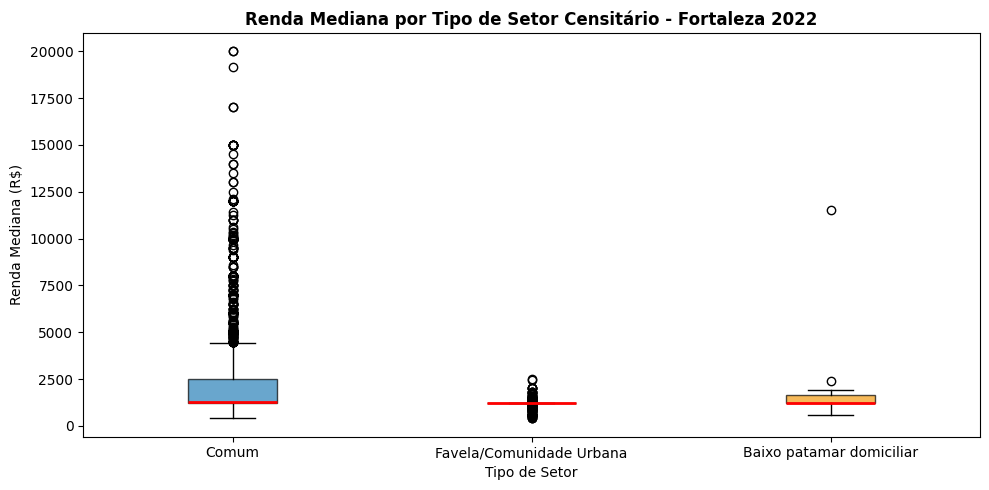


Estatísticas por tipo de setor:
                           count     mean      std    min     25%     50%  \
TIPO_LABEL                                                                  
Baixo patamar domiciliar    14.0  2063.57  2749.72  600.0  1200.0  1212.0   
Comum                     2947.0  2516.70  2460.71  400.0  1212.0  1300.0   
Favela/Comunidade Urbana  1318.0  1199.83   141.49  400.0  1200.0  1212.0   

                             75%      max  
TIPO_LABEL                                 
Baixo patamar domiciliar  1637.5  11500.0  
Comum                     2500.0  20001.0  
Favela/Comunidade Urbana  1212.0   2500.0  


In [ ]:
tipos_analise = ['Comum', 'Favela/Comunidade Urbana', 'Baixo patamar domiciliar']
df_tipo = df_merged[df_merged['TIPO_LABEL'].isin(tipos_analise)]

fig, ax = plt.subplots(figsize=(10, 5))

data_box = [df_tipo[df_tipo['TIPO_LABEL'] == t]['RENDA_MEDIANA'].dropna().values
            for t in tipos_analise]

bp = ax.boxplot(data_box, labels=tipos_analise, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

cores_box = ['#2980b9', '#e74c3c', '#f39c12']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_title('Renda Mediana por Tipo de Setor Censitário - Fortaleza 2022', fontweight='bold')
ax.set_ylabel('Renda Mediana (R$)')
ax.set_xlabel('Tipo de Setor')
plt.tight_layout()
plt.savefig('renda_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEstatísticas por tipo de setor:')
print(df_tipo.groupby('TIPO_LABEL')['RENDA_MEDIANA'].describe().round(2))

### 5.4 Correlação entre Variáveis

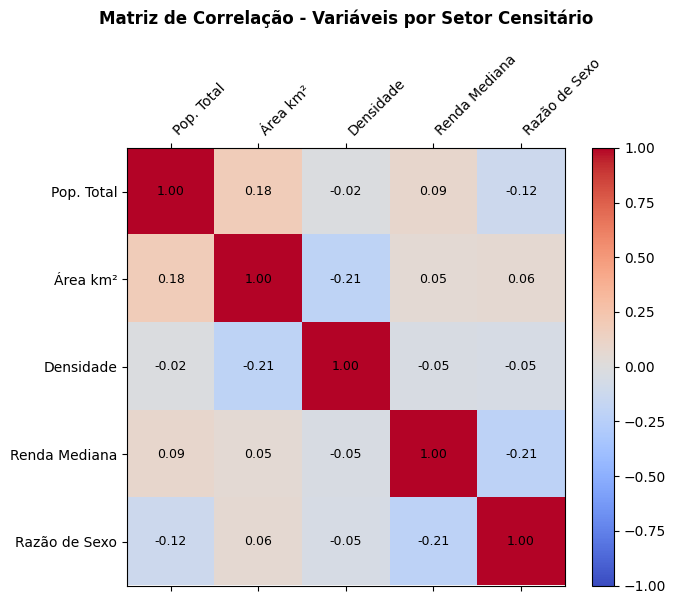

In [ ]:
colunas_corr = [c for c in ['POP_TOTAL', 'AREA_KM2', 'DENSIDADE', 'RENDA_MEDIANA', 'RAZAO_SEXO']
                if c in df_merged.columns]

corr = df_merged[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

labels = {
    'POP_TOTAL': 'Pop. Total', 'AREA_KM2': 'Área km²',
    'DENSIDADE': 'Densidade', 'RENDA_MEDIANA': 'Renda Mediana',
    'RAZAO_SEXO': 'Razão de Sexo'
}
tick_labels = [labels.get(c, c) for c in colunas_corr]
ax.set_xticks(range(len(colunas_corr)))
ax.set_yticks(range(len(colunas_corr)))
ax.set_xticklabels(tick_labels, rotation=45, ha='left', fontsize=10)
ax.set_yticklabels(tick_labels, fontsize=10)

for i in range(len(colunas_corr)):
    for j in range(len(colunas_corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Matriz de Correlação - Variáveis por Setor Censitário', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Densidade Populacional vs. Renda Mediana

---
## 6. Visualização e Comunicação dos Resultados


### 6.1 Renda Mediana por Setor Censitário

In [ ]:
# 15 bairros com maior e 15 com menor renda mediana
top15 = bairros_gdf.nlargest(15, 'RENDA_MEDIANA')[['NM_BAIRRO', 'RENDA_MEDIANA']]
bottom15 = bairros_gdf.nsmallest(15, 'RENDA_MEDIANA')[['NM_BAIRRO', 'RENDA_MEDIANA']]

fig_top = px.bar(
    top15, x='RENDA_MEDIANA', y='NM_BAIRRO', orientation='h',
    title='Top 15 bairros com MAIOR renda mediana (interativo)'
)
fig_top.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_top.show()

fig_bottom = px.bar(
    bottom15, x='RENDA_MEDIANA', y='NM_BAIRRO', orientation='h',
    title='Top 15 bairros com MENOR renda mediana (interativo)'
)
fig_bottom.update_layout(yaxis={'categoryorder': 'total descending'})
fig_bottom.show()


### 6.2 Gráficos Interativos - Quantidades de Tipos de Setores

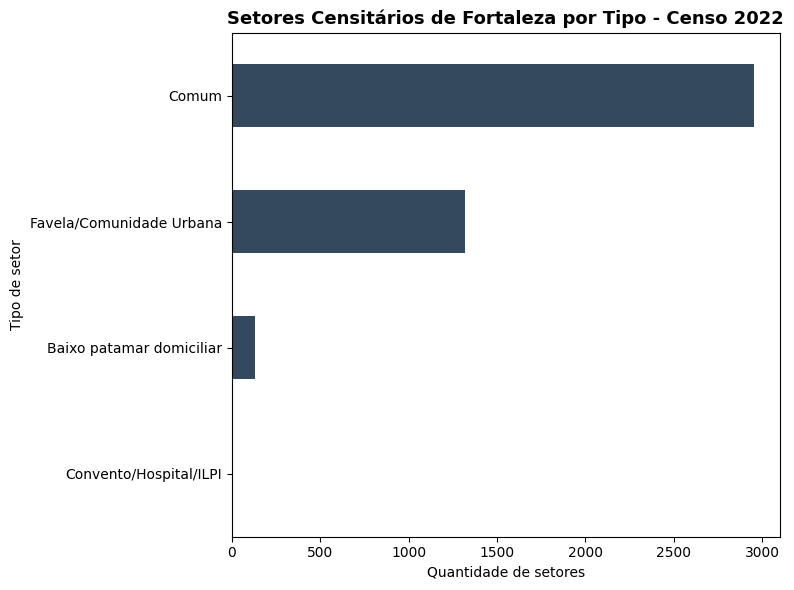

In [ ]:
# conta quantos setores existem de cada tipo
contagem_tipos = setores_fortaleza['TIPO_LABEL'].value_counts()

plt.figure(figsize=(8, 6))
contagem_tipos.sort_values().plot(kind='barh', color='#34495e')
plt.title('Setores Censitários de Fortaleza por Tipo - Censo 2022', fontsize=13, fontweight='bold')
plt.xlabel('Quantidade de setores')
plt.ylabel('Tipo de setor')
plt.tight_layout()
plt.savefig('contagem_tipo_setor.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Distribuição Interativa de Setores por Tipo

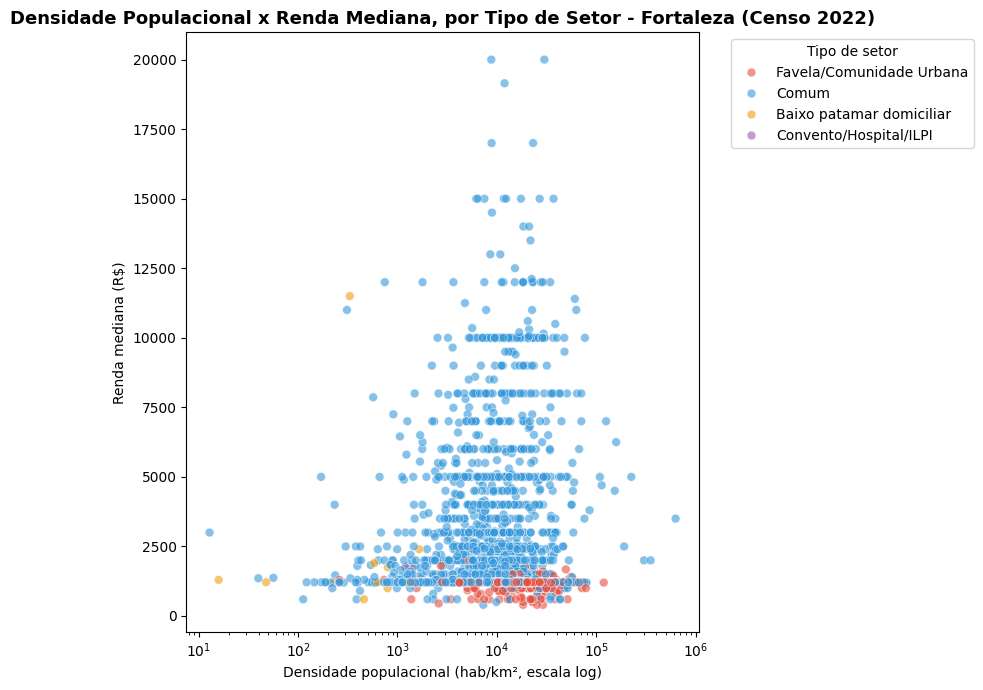

In [ ]:
cores_tipo = {
    'Comum': '#3498db',
    'Favela/Comunidade Urbana': '#e74c3c',
    'Baixo patamar domiciliar': '#f39c12',
    'Convento/Hospital/ILPI': '#9b59b6'
}
df_scatter = df_merged[df_merged['TIPO_LABEL'].isin(cores_tipo.keys())].dropna(subset=['DENSIDADE', 'RENDA_MEDIANA'])

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_scatter, x='DENSIDADE', y='RENDA_MEDIANA',
    hue='TIPO_LABEL', palette=cores_tipo, alpha=0.6, s=40
)
plt.xscale('log')
plt.title('Densidade Populacional x Renda Mediana, por Tipo de Setor - Fortaleza (Censo 2022)', fontsize=13, fontweight='bold')
plt.xlabel('Densidade populacional (hab/km², escala log)')
plt.ylabel('Renda mediana (R$)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tipo de setor')
plt.tight_layout()
plt.savefig('densidade_vs_renda.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Histograma Interativo - Renda por Tipo de Setor

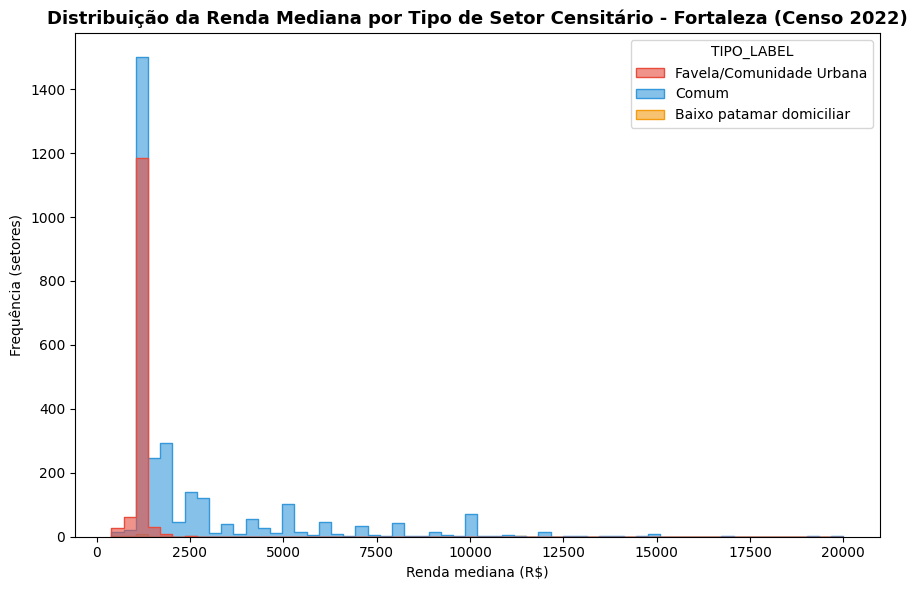

In [ ]:
# mantém só os 3 tipos com dados suficientes para comparar
tipos_analise = ['Comum', 'Favela/Comunidade Urbana', 'Baixo patamar domiciliar']
df_hist = df_merged[df_merged['TIPO_LABEL'].isin(tipos_analise)].dropna(subset=['RENDA_MEDIANA'])

plt.figure(figsize=(9, 6))
sns.histplot(
    data=df_hist, x='RENDA_MEDIANA', hue='TIPO_LABEL', bins=60,
    palette={'Comum': '#3498db', 'Favela/Comunidade Urbana': '#e74c3c', 'Baixo patamar domiciliar': '#f39c12'},
    alpha=0.6, element='step'
)
plt.title('Distribuição da Renda Mediana por Tipo de Setor Censitário - Fortaleza (Censo 2022)', fontsize=13, fontweight='bold')
plt.xlabel('Renda mediana (R$)')
plt.ylabel('Frequência (setores)')
plt.tight_layout()
plt.savefig('hist_renda_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4.2 Distribuição da Renda Mediana por Tipo de Setor, sem Outliers

Comum: 444 outliers removidos de 2947 (limite IQR: R$ -720 a R$ 4,432)
Favela/Comunidade Urbana: 200 outliers removidos de 1318 (limite IQR: R$ 1,182 a R$ 1,230)
Baixo patamar domiciliar: 2 outliers removidos de 14 (limite IQR: R$ 544 a R$ 2,294)


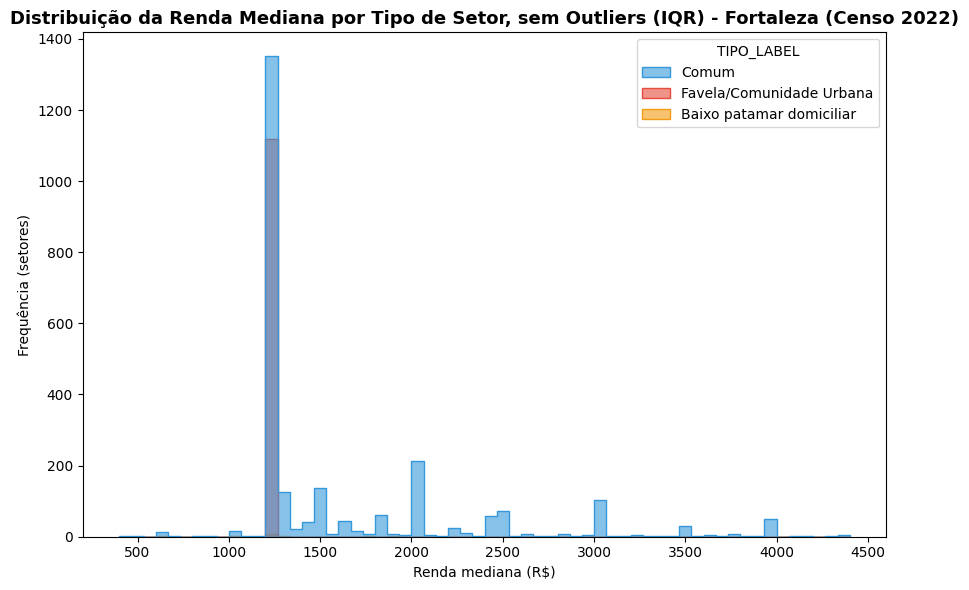

In [ ]:
grupos_sem_outliers = []
for tipo in tipos_analise:
    valores = df_hist.loc[df_hist['TIPO_LABEL'] == tipo, 'RENDA_MEDIANA']
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    subset = df_hist[
        (df_hist['TIPO_LABEL'] == tipo) &
        (df_hist['RENDA_MEDIANA'] >= limite_inferior) &
        (df_hist['RENDA_MEDIANA'] <= limite_superior)
    ]
    grupos_sem_outliers.append(subset)
    print(f'{tipo}: {len(valores) - len(subset)} outliers removidos de {len(valores)} '
          f'(limite IQR: R$ {limite_inferior:,.0f} a R$ {limite_superior:,.0f})')

df_hist_sem_outliers = pd.concat(grupos_sem_outliers)

plt.figure(figsize=(9, 6))
sns.histplot(
    data=df_hist_sem_outliers, x='RENDA_MEDIANA', hue='TIPO_LABEL', bins=60
  ,
    palette={'Comum': '#3498db', 'Favela/Comunidade Urbana': '#e74c3c', 'Baixo patamar domiciliar': '#f39c12'},
    alpha=0.6, element='step'
)
plt.title('Distribuição da Renda Mediana por Tipo de Setor, sem Outliers (IQR) - Fortaleza (Censo 2022)', fontsize=13, fontweight='bold')
plt.xlabel('Renda mediana (R$)')
plt.ylabel('Frequência (setores)')
plt.tight_layout()
plt.savefig('hist_renda_por_tipo_sem_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Mapa de Setores Favela e Mapa de Baixa Renda

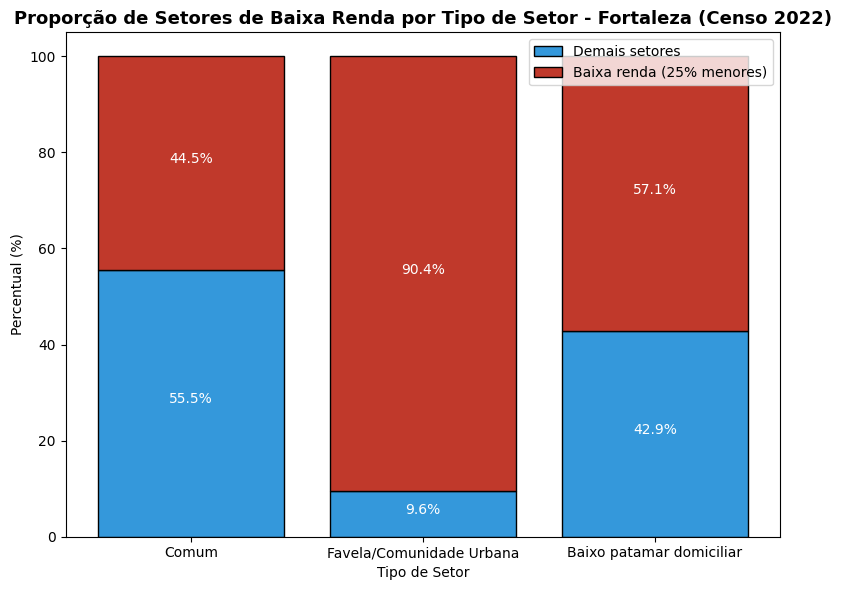

In [ ]:
limite_baixa_renda = df_merged['RENDA_MEDIANA'].quantile(0.25)
df_merged['FAIXA_RENDA'] = np.where(
    df_merged['RENDA_MEDIANA'] <= limite_baixa_renda, 'Baixa renda (25% menores)', 'Demais setores'
)

tipos_analise = ['Comum', 'Favela/Comunidade Urbana', 'Baixo patamar domiciliar']
df_tipo_renda = df_merged[df_merged['TIPO_LABEL'].isin(tipos_analise) & df_merged['RENDA_MEDIANA'].notna()]

contagem = pd.crosstab(df_tipo_renda['TIPO_LABEL'], df_tipo_renda['FAIXA_RENDA']).reindex(tipos_analise)
perc_baixa = (contagem['Baixa renda (25% menores)'] / contagem.sum(axis=1) * 100)
perc_demais = 100 - perc_baixa

plt.figure(figsize=(8, 6))
plt.bar(tipos_analise, perc_demais, label='Demais setores', color='#3498db', edgecolor='black')
plt.bar(tipos_analise, perc_baixa, bottom=perc_demais, label='Baixa renda (25% menores)', color='#c0392b', edgecolor='black')

for i, tipo in enumerate(tipos_analise):
    plt.text(i, perc_demais.iloc[i] / 2, f'{perc_demais.iloc[i]:.1f}%', ha='center', color='white', fontsize=10)
    plt.text(i, perc_demais.iloc[i] + perc_baixa.iloc[i] / 2, f'{perc_baixa.iloc[i]:.1f}%', ha='center', color='white', fontsize=10)

plt.title('Proporção de Setores de Baixa Renda por Tipo de Setor - Fortaleza (Censo 2022)', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Setor')
plt.ylabel('Percentual (%)')
plt.legend()
plt.tight_layout()
plt.savefig('baixa_renda_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()


# Seção 7. Conclusões e Discussão

## 7.1 Principais Descobertas

A análise dos dados do Censo 2022 para os **4.408 setores censitários de Fortaleza** revelou padrões estruturais de desigualdade socioespacial significativos:

**1. Concentração espacial da renda**

O mapeamento da renda mediana por setor censitário (Seção 6.5 e mapa coroplético) mostra que a renda não se distribui de forma difusa pelo território: os valores mais altos se concentram em uma faixa litorânea/central restrita — bairros como Cocó, Guararapes, Meireles, Aldeota, Dionísio Torres e Varjota —, enquanto a ampla maioria da mancha urbana, sobretudo nas periferias oeste, sul e sudeste, permanece próxima do piso da distribuição (R\$ 1.212, valor modal). A diferença entre o bairro de maior renda mediana (Cocó/Guararapes, R\$ 10.000) e o de menor renda (Barroso, R\$ 1.200) chega a **8,3 vezes**, evidenciando desigualdade intraurbana acentuada.

**2. Favelas e baixa renda**

Dos 4.408 setores de Fortaleza, 1.321 (30,0%) são classificados pelo IBGE como Favela/Comunidade Urbana e 133 (3,0%) como Baixo patamar domiciliar. A renda mediana média nos setores do tipo "Comum" é de R\$ 2.516,70, contra apenas R\$ 1.199,83 nos setores de Favela/Comunidade Urbana — menos da metade — e com desvio padrão bem menor (R\$ 141,49 vs. R\$ 2.460,71), indicando que a renda nesses setores está fortemente concentrada perto do piso da distribuição, com pouca variação interna. Essa disparidade se confirma ao segmentar os setores pela faixa de menor renda (25% inferiores, ≤ R\$ 1.212): **90,4%** dos setores de Favela/Comunidade Urbana estão nessa faixa, contra 44,5% dos setores Comuns e 57,1% dos setores de Baixo patamar domiciliar.

**3. Coeficiente de Gini**

O Coeficiente de Gini calculado sobre a renda mediana por setor é de **0,3696** (0 = igualdade perfeita; 1 = desigualdade máxima), indicando elevada desigualdade intraurbana, consistente com a literatura sobre cidades nordestinas brasileiras.

**4. Densidade e renda**

A matriz de correlação (Seção 5.4) mostra que a renda mediana tem correlação fraca com densidade populacional (r = -0,05), área do setor (r = 0,05) e população total (r = 0,09). A correlação mais expressiva da tabela é entre renda e razão de sexo (r = -0,21), ainda assim fraca. Isso sugere que, isoladamente, essas variáveis demográficas e de ocupação do território não explicam a desigualdade de renda observada — o fator mais associado à renda parece ser a localização e o tipo de setor censitário (Comum vs. Favela/Comunidade Urbana), e não a densidade ou o tamanho da população residente.

## 7.2 Limitações

- Valores suprimidos pelo IBGE (`X`) em setores com poucos domicílios limitam a cobertura, especialmente em áreas rurais e setores especiais: 840 dos 4.408 setores ficaram com dados demográficos incompletos, e 26 setores não têm renda mediana disponível.
- A variável `V06006` captura o rendimento do **responsável pelo domicílio**, não a renda per capita familiar, o que pode subestimar a desigualdade real.
- Observa-se repetição exata de valores de renda mediana entre setores/bairros distintos (por exemplo, vários bairros empatados em R\$ 1.212, e o próprio teto de R\$ 10.000 atingido simultaneamente por Cocó e Guararapes). Esse padrão é consistente com arredondamento ou proteção de sigilo estatístico aplicada pelo IBGE na divulgação da renda mediana, e não com um erro de processamento — mas limita a granularidade da análise nos extremos da distribuição.
- A análise é transversal (ponto no tempo); comparações longitudinais com censos anteriores ampliariam o poder explicativo.

## 7.3 Trabalhos Futuros

- Integrar dados de acesso a serviços (saúde, educação, saneamento) para análise multidimensional da pobreza.
- Comparar com dados do Censo 2010 para medir evolução da desigualdade ao longo de 12 anos.
- Aprofundar a análise espacial com estatísticas de autocorrelação (ex.: Índice de Moran) para testar formalmente a existência de clusters (*hot spots*) de renda alta e baixa, complementando a leitura visual do mapa coroplético.

## 8. Referências

- IBGE. **Censo Demográfico 2022 – Resultados do Universo**. Disponível em: https://www.ibge.gov.br/estatisticas/sociais/trabalho/22827-censo-demografico-2022.html
- IBGE. **Malhas Territoriais – Setores Censitários 2022**. Disponível em: https://www.ibge.gov.br/geociencias/downloads-geociencias.html
- GeoPandas Documentation. https://geopandas.org
- Plotly Express Documentation. https://plotly.com/python/plotly-express/